# 极限连续与导数

学习目标：理解极限、连续与可导的区别，手算常见函数及复合函数的导数，用切线作局部预测，并通过步长实验判断差分近似的适用范围。

前置知识：实数函数与定义域、指数与对数、基本三角函数、直线斜率；Python 函数、循环与数组基本操作。

运行环境：Python 3.12、NumPy 2.5、Matplotlib 3.11。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 极限描述的是怎样逼近

### 1.1 函数在一点没有值，仍可能有极限

考虑实函数 $f(x)=(x^2-1)/(x-1)$，定义域为 $x\ne1$。它不能在 $x=1$ 直接求值，但在其他位置有

$$f(x)=\frac{(x-1)(x+1)}{x-1}=x+1.$$

当 $x$ 从两侧靠近 1 时，$f(x)$ 靠近 2，记为 $\lim_{x\to1}f(x)=2$。极限关注邻近位置的行为，不要求该点已有函数值。下面先观察几组输入；有限表格只能帮助发现规律，不能证明极限。

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def ratio(x):
    return (x**2 - 1) / (x - 1)


for h in (0.1, 0.01, 0.001):
    print(f"h={h:.3f}，左侧={ratio(1 - h):.6f}，右侧={ratio(1 + h):.6f}")  # 左右函数值分别从 1.9、2.1 靠近 2，最后一组为 1.999、2.001。
# 左侧为 1.9、1.99、1.999，右侧为 2.1、2.01、2.001。
# 不调用 ratio(1)：约分后的表达式没有自动补上原函数缺失的定义。

h=0.100，左侧=1.900000，右侧=2.100000
h=0.010，左侧=1.990000，右侧=2.010000
h=0.001，左侧=1.999000，右侧=2.001000


### 1.2 “足够接近”的含义

设实函数 $f$ 在实数 $a$ 附近有定义，允许缺少 $a$ 这一点。有限极限 $\lim_{x\to a}f(x)=L$ 的含义是：对任意误差要求 $\varepsilon>0$，都能找到邻域宽度 $\delta>0$，使

$$0<|x-a|<\delta\quad\Longrightarrow\quad|f(x)-L|<\varepsilon.$$

其中 $L$ 是实数，$\varepsilon$ 控制输出误差，$\delta$ 控制输入距离；$0<|x-a|$ 排除了 $x=a$。$\delta$ 可以依赖 $\varepsilon$，但必须约束这个邻域中的所有输入，不能只挑一条好看的数列。

对前面的例子，$|f(x)-2|=|x-1|$，直接取 $\delta=\varepsilon$ 即可。这一步对所有满足条件的 $x$ 成立，才给出了证明。下面的抽样仅用于核对不等式。

In [2]:
epsilon = 0.02
delta = epsilon
offsets = delta * np.array([-0.9, -0.4, 0.3, 0.8])
x = 1 + offsets
errors = np.abs((x + 1) - 2)

print("输入距离：", np.abs(offsets))  # 预期约为 [0.018 0.008 0.006 0.016]。
print("输出误差：", errors)  # 预期约为 [0.018 0.008 0.006 0.016]。
print("抽样点满足误差要求：", np.all(errors < epsilon))  # True。

输入距离： [0.018 0.008 0.006 0.016]
输出误差： [0.018 0.008 0.006 0.016]
抽样点满足误差要求： True


### 1.3 单侧极限必须分开看

$x\to a^-$ 表示只从 $a$ 左侧逼近，$x\to a^+$ 表示只从右侧逼近。对两侧邻近位置都有定义的函数，双侧有限极限存在，当且仅当左右极限都存在且相等。

取阶跃函数 $g(x)=0$（$x<0$），$g(x)=1$（$x\geq0$）。左极限是 0，右极限是 1，因此在 0 处没有双侧极限。即使把 $g(0)$ 改成其他数，也不会改变两侧极限。

In [3]:
def step(x):
    return np.where(x < 0, 0.0, 1.0)


for h in (0.1, 0.01, 0.001):
    print(f"h={h:.3f}，g(-h)={step(-h):.1f}，g(h)={step(h):.1f}")  # 每个 h 的左值均为 0、右值均为 1，缩小 h 没有消除跳跃。
print("g(0)：", step(0.0))  # 1；该值不能让两个不同的单侧极限相等。

h=0.100，g(-h)=0.0，g(h)=1.0
h=0.010，g(-h)=0.0，g(h)=1.0
h=0.001，g(-h)=0.0，g(h)=1.0
g(0)： 1.0


### 1.4 极限运算的条件

若 $\lim_{x\to a}u(x)=A$、$\lim_{x\to a}v(x)=B$ 都是有限实数，$c$ 是实常数，则和、差、数乘与乘积可以分别取极限：

$$\lim(u\pm v)=A\pm B,\qquad \lim(cu)=cA,\qquad \lim(uv)=AB.$$

这里各个 $\lim$ 都指 $x\to a$。商满足 $\lim(u/v)=A/B$ 的条件是 $B\ne0$。例如 $\lim_{x\to1}(x^2+2)/(x+1)=3/2$；而开篇例子的分母极限为 0，不能直接套商法则得到“0 除以 0”。应先在 $x\ne1$ 时约分，再求极限。

In [4]:
for x in (0.99, 0.999, 1.001, 1.01):
    value = (x**2 + 2) / (x + 1)
    print(f"x={x:.3f}，函数值={value:.6f}")  # x 从两侧靠近 1 时，值靠近 1.5；四个值约为 1.49754、1.49975、1.50025、1.50254。
print("按极限运算法则计算：", (1**2 + 2) / (1 + 1))  # 1.5。

x=0.990，函数值=1.497538
x=0.999，函数值=1.499750
x=1.001，函数值=1.500250
x=1.010，函数值=1.502537
按极限运算法则计算： 1.5


## 2 连续要求极限与该点取值接上

在定义域内部，$f$ 在 $a$ 处连续，需要同时满足：$f(a)$ 有定义，$\lim_{x\to a}f(x)$ 存在，且这个极限等于 $f(a)$。

把开篇函数补成 $F_k(x)=x+1$（$x\ne1$），$F_k(1)=k$，其中 $k\in\mathbb R$。所有这些函数在 1 处的极限都是 2；只有 $k=2$ 时连续。$k=0$ 时存在可去间断点（removable discontinuity），改变一个点的取值就能接上；阶跃函数的跳跃则无法这样修补。

下面两幅图分别画 $F_0$ 和阶跃函数。空心圆表示该段图形排除的端点，实心圆表示函数真正的取值。

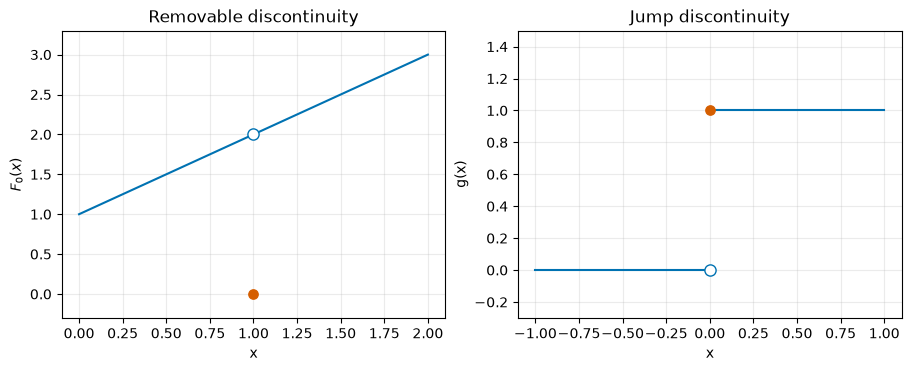

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), layout="constrained")
x = np.linspace(0, 2, 201)
axes[0].plot(x, x + 1, color="#0072B2")
axes[0].scatter([1], [2], s=65, facecolors="white", edgecolors="#0072B2", zorder=3)
axes[0].scatter([1], [0], s=45, color="#D55E00", zorder=3)
axes[0].set(xlabel="x", ylabel=r"$F_0(x)$", title="Removable discontinuity")
axes[0].set_ylim(-0.3, 3.3)

axes[1].plot([-1, 0], [0, 0], color="#0072B2")
axes[1].plot([0, 1], [1, 1], color="#0072B2")
axes[1].scatter([0], [0], s=65, facecolors="white", edgecolors="#0072B2", zorder=3)
axes[1].scatter([0], [1], s=45, color="#D55E00", zorder=3)
axes[1].set(xlabel="x", ylabel="g(x)", title="Jump discontinuity")
axes[1].set_ylim(-0.3, 1.5)
for ax in axes:
    ax.grid(alpha=0.25)
# 左图可以把实心点移至空心位置接上；右图无论怎样修改 g(0) 都接不上两侧。
plt.show()

## 3 从割线斜率到导数

### 3.1 差商的极限

对 $f(x)=x^2$，从 $(1,1)$ 到 $(1+h,(1+h)^2)$ 的割线斜率为

$$\frac{f(1+h)-f(1)}{h}=\frac{2h+h^2}{h}=2+h,\qquad h\ne0.$$

因此两侧的 $h$ 趋于 0 时，斜率都趋于 2。一般地，设 $a$ 是实函数 $f$ 定义域的内点，$h$ 是满足 $a+h$ 在定义域内的非零增量。若有限极限存在，则定义导数（derivative）为

$$f'(a)=\lim_{h\to0}\frac{f(a+h)-f(a)}{h}.$$

分式称为差商。$f'(a)$ 是一个点的局部变化率；把可导位置 $x$ 对应的值放在一起，才得到导函数 $f'(x)$，也记作 $\mathrm df/\mathrm dx$。不能先令 $h=0$ 再做除法。

In [6]:
a = 1.0
for h in (-0.5, -0.1, -0.01, 0.01, 0.1, 0.5):
    slope = ((a + h) ** 2 - a**2) / h
    print(f"h={h:5.2f}，割线斜率={slope:.4f}，与 2 的差={slope - 2:+.4f}")  # 割线斜率为 2+h；h=±0.01 时分别为 1.99、2.01。
# 代数公式给出 slope = 2 + h；两侧分别趋近同一个数。

h=-0.50，割线斜率=1.5000，与 2 的差=-0.5000
h=-0.10，割线斜率=1.9000，与 2 的差=-0.1000
h=-0.01，割线斜率=1.9900，与 2 的差=-0.0100
h= 0.01，割线斜率=2.0100，与 2 的差=+0.0100
h= 0.10，割线斜率=2.1000，与 2 的差=+0.1000
h= 0.50，割线斜率=2.5000，与 2 的差=+0.5000


### 3.2 切线由位置和局部斜率共同确定

当 $f'(a)$ 存在时，切线方程为 $y=f(a)+f'(a)(x-a)$。在 $x^2$ 的 $a=1$ 处，它是 $y=1+2(x-1)$。

图中保持相同坐标范围和等比例坐标，比较 $h=0.8$ 与 $h=0.2$ 的割线。割线穿过曲线上两个点；切线由极限斜率确定，不是把曲线上一段有限长度的线段重新命名。

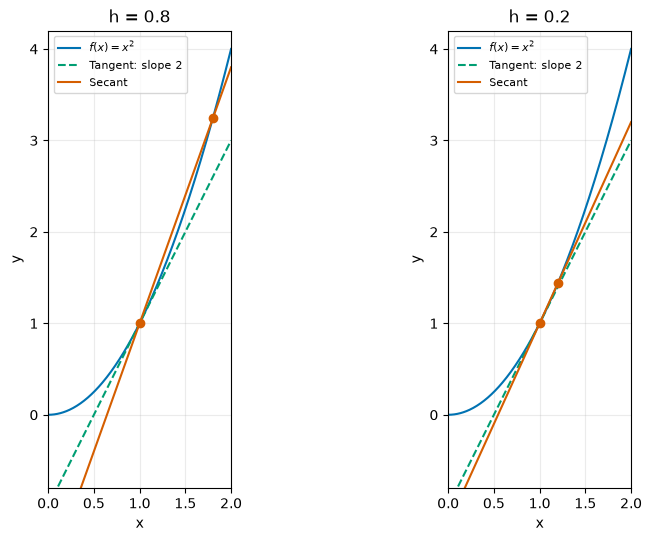

In [7]:
x = np.linspace(0, 2, 301)
fig, axes = plt.subplots(1, 2, figsize=(8, 5.3), layout="constrained")
for ax, h in zip(axes, (0.8, 0.2)):
    secant_slope = 2 + h
    ax.plot(x, x**2, color="#0072B2", label=r"$f(x)=x^2$")
    ax.plot(x, 1 + 2 * (x - 1), "--", color="#009E73", label="Tangent: slope 2")
    ax.plot(x, 1 + secant_slope * (x - 1), color="#D55E00", label="Secant")
    ax.scatter([1, 1 + h], [1, (1 + h) ** 2], color="#D55E00", zorder=3)
    ax.set(xlim=(0, 2), ylim=(-0.8, 4.2), xlabel="x", ylabel="y", title=f"h = {h}")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)
# 割线斜率从 2.8 变为 2.2，更接近切线斜率 2。
plt.show()

### 3.3 变化率有自己的单位

若 $s(t)$ 表示位置，单位为米，$t$ 以秒计，那么差商 $[s(t+h)-s(t)]/h$ 表示这段时间的平均速度，单位为米每秒；导数 $s'(t)$ 是瞬时速度，单位相同。

用教学模型 $s(t)=t^2$ 表示位置的数值，$t\geq0$，其中二次项系数隐含单位 $\mathrm{m/s^2}$。在 $t=2$ 秒时，$s'(2)=4\ \mathrm{m/s}$；从 2 秒到 3 秒的平均速度却为 5 米每秒。局部变化率不等于整个时间段的平均变化率。

In [8]:
t = 2.0
for duration in (1.0, 0.1, 0.01):
    average_velocity = ((t + duration) ** 2 - t**2) / duration
    print(f"时间间隔 {duration:.2f} s，平均速度 {average_velocity:.4f} m/s")  # 三个平均速度依次为 5、4.1、4.01 m/s，靠近瞬时速度 4 m/s。
print("2 s 时的瞬时速度：", 2 * t, "m/s")  # 4 m/s。

时间间隔 1.00 s，平均速度 5.0000 m/s
时间间隔 0.10 s，平均速度 4.1000 m/s
时间间隔 0.01 s，平均速度 4.0100 m/s
2 s 时的瞬时速度： 4.0 m/s


## 4 连续、可导与单侧行为

### 4.1 可导一定连续，连续未必可导

若 $f'(a)$ 存在且有限，对 $h\ne0$ 有

$$f(a+h)-f(a)=h\frac{f(a+h)-f(a)}h\ \longrightarrow\ 0\cdot f'(a)=0.$$

因此 $f(a+h)\to f(a)$，即在 $a$ 处可导必然连续。反过来，$f(x)=|x|$ 在 0 处连续，但其差商为 $|h|/h$：左侧恒为 $-1$，右侧恒为 $1$，所以没有导数。

左导数与右导数分别把导数定义中的 $h\to0$ 换为 $h\to0^-$ 与 $h\to0^+$。在内点处，需要两者存在、有限且相等，才能得到通常的双侧导数。

In [9]:
for h in (0.1, 0.01, 0.001):
    left_slope = (abs(-h) - abs(0.0)) / (-h)
    right_slope = (abs(h) - abs(0.0)) / h
    print(f"h={h:.3f}，左侧差商={left_slope:.1f}，右侧差商={right_slope:.1f}")  # 三次左差商均为 -1，右差商均为 1。
# 左右斜率始终不同；缩小步长无法消除尖角。

h=0.100，左侧差商=-1.0，右侧差商=1.0
h=0.010，左侧差商=-1.0，右侧差商=1.0
h=0.001，左侧差商=-1.0，右侧差商=1.0


### 4.2 定义域端点只允许从一侧靠近

函数 $q(x)=\sqrt{x}$ 的实数定义域是 $[0,+\infty)$。在端点 0 处，$\lim_{x\to0^+}q(x)=q(0)=0$，所以它在端点右连续。闭区间上的连续性，在左右端点分别使用右连续和左连续。

但这里右侧差商为 $\sqrt{h}/h=1/\sqrt{h}$（$h>0$），当 $h\to0^+$ 时无界增长，没有有限的右导数。写作“趋于 $+\infty$”描述这种无界行为，$+\infty$ 不是本章定义中的实数导数。也不能为了计算左侧差商而把负数输入实数平方根。

In [10]:
for h in (1e-2, 1e-4, 1e-6):
    function_value = np.sqrt(h)
    right_slope = function_value / h
    print(f"h={h:.0e}，函数值={function_value:.3f}，右侧差商={right_slope:.1f}")  # 函数值为 0.1、0.01、0.001；右差商却为 10、100、1000。
# 函数值趋近 0，但差商为 10、100、1000，不能据连续性推断可导。

h=1e-02，函数值=0.100，右侧差商=10.0
h=1e-04，函数值=0.010，右侧差商=100.0
h=1e-06，函数值=0.001，右侧差商=1000.0


## 5 用求导规则处理常见表达式

### 5.1 基本导数与适用范围

由定义展开 $(x+h)^n-x^n$，除以 $h$ 后，除 $nx^{n-1}$ 外的各项都含正次幂的 $h$；取极限便得到正整数幂的求导规则。常用公式如下，$c$ 是实常数，$p$ 是固定实数。

| 函数 | 导数 | 本表使用的条件 |
| --- | --- | --- |
| $c$ | $0$ | $x\in\mathbb R$ |
| $x^n$ | $nx^{n-1}$ | $n$ 为正整数，$x\in\mathbb R$；$n=1$ 时导数恒为 1 |
| $x^p$ | $px^{p-1}$ | 一般实指数先限定 $x>0$ |
| $e^x$ | $e^x$ | $x\in\mathbb R$ |
| $\ln x$ | $1/x$ | $x>0$ |
| $\sin x$ | $\cos x$ | $x\in\mathbb R$，角度按弧度计 |
| $\cos x$ | $-\sin x$ | $x\in\mathbb R$，角度按弧度计 |

指数、对数和三角函数的公式在这里作为已建立的求导结论使用，不通过有限差分实验来证明。np.log 表示自然对数，np.exp 表示自然指数；它们计算函数值，不会自动对 Python 函数求导。

In [11]:
x = 2.0
print("x³ 的值与导数：", x**3, 3 * x**2)  # 8 与 12。
print("√x 的值与导数：", np.sqrt(x), 1 / (2 * np.sqrt(x)))  # 预期约为 1.41421 0.353553。
print("exp(x) 的值与导数：", np.exp(x), np.exp(x))  # 预期约为 7.38906 7.38906。
print("ln(x) 的值与导数：", np.log(x), 1 / x)  # 预期约为 0.693147 0.5。

angle = np.pi / 3
print("sin(x) 的值与导数：", np.sin(angle), np.cos(angle))  # √3/2 与 1/2。
print("cos(x) 的导数：", -np.sin(angle))  # -√3/2。

x³ 的值与导数： 8.0 12.0
√x 的值与导数： 1.4142135623730951 0.35355339059327373
exp(x) 的值与导数： 7.38905609893065 7.38905609893065
ln(x) 的值与导数： 0.6931471805599453 0.5
sin(x) 的值与导数： 0.8660254037844386 0.5000000000000001
cos(x) 的导数： -0.8660254037844386


### 5.2 和、数乘、乘积与商

设 $u,v$ 在所讨论的点可导，$c$ 是实常数。和与数乘分别求导；乘积则有两项：

$$\begin{aligned}
(u+v)'&=u'+v',& (cu)'&=cu',\\
(uv)'&=u'v+uv',& \left(\frac uv\right)'&=\frac{u'v-uv'}{v^2}\quad(v\ne0).
\end{aligned}$$

乘积法则可由差商中加减 $u(a)v(a+h)$ 看出来：

$$\frac{u(a+h)v(a+h)-u(a)v(a)}h
=\frac{u(a+h)-u(a)}h\,v(a+h)
+u(a)\frac{v(a+h)-v(a)}h.$$

取极限，利用 $v$ 可导所以连续，就得到两项之和。导数不是把原式中所有函数都简单换成各自导数。

例如 $P(x)=(x^2+1)(x-2)$ 的导数是 $2x(x-2)+(x^2+1)$。展开 $P=x^3-2x^2+x-2$ 后求导得到 $3x^2-4x+1$，两种写法应一致。

In [12]:
x = np.array([-1.0, 0.0, 2.0])
product_derivative = 2 * x * (x - 2) + (x**2 + 1)
expanded_derivative = 3 * x**2 - 4 * x + 1
print("按乘积法则：", product_derivative)  # [8, 1, 5]。
print("展开后求导：", expanded_derivative)  # 预期为 [8. 1. 5.]。
print("结果一致：", np.allclose(product_derivative, expanded_derivative))  # 预期为 True。

按乘积法则： [8. 1. 5.]
展开后求导： [8. 1. 5.]
结果一致： True


### 5.3 商法则要保留定义域

对 $R(x)=(x^2+1)/(x+2)$，定义域要求 $x\ne-2$。商法则给出

$$R'(x)=\frac{2x(x+2)-(x^2+1)}{(x+2)^2}
=\frac{x^2+4x-1}{(x+2)^2}.$$

也可先写成 $R(x)=x-2+5/(x+2)$，再得到 $R'(x)=1-5/(x+2)^2$。化简能够帮助核对，但不会让被排除的 $x=-2$ 重新进入定义域。

In [13]:
x = np.array([-1.0, 0.0, 1.0])
quotient_derivative = (2 * x * (x + 2) - (x**2 + 1)) / (x + 2) ** 2
rewritten_derivative = 1 - 5 / (x + 2) ** 2
print("按商法则：", quotient_derivative)  # 预期约为 [-4. -0.25 0.444444]。
print("重写后求导：", rewritten_derivative)  # 预期约为 [-4. -0.25 0.444444]。
print("结果一致：", np.allclose(quotient_derivative, rewritten_derivative))  # 预期为 True。
# 在这些合法输入上核对一致；不向公式传入 -2。

按商法则： [-4.         -0.25        0.44444444]
重写后求导： [-4.         -0.25        0.44444444]
结果一致： True


## 6 复合函数逐层求导

若 $u=g(x)$ 在 $x$ 处可导，外层函数 $f$ 在 $u=g(x)$ 处可导，则链式法则（chain rule）给出

$$F(x)=f(g(x)),\qquad F'(x)=f'(g(x))g'(x).$$

先对外层求导并代入内层的值，再乘以内层导数。符号 $\mathrm dy/\mathrm dx=(\mathrm dy/\mathrm du)(\mathrm du/\mathrm dx)$ 表达这个复合规则；这里的导数记号不能任意当作普通分数约掉。

对 $F(x)=\ln(3x^2+1)$，内层 $g(x)=3x^2+1>0$，外层 $f(u)=\ln u$，因此整个实数轴都在定义域中，并且

$$F'(x)=\frac{1}{3x^2+1}\cdot6x=\frac{6x}{3x^2+1}.$$

在 $x=1$ 处，外层导数是 $1/4$，内层导数是 6，乘积才是 $3/2$。只算 $1/(3x^2+1)$ 会漏掉内层变化。

In [14]:
x = 1.0
inner_value = 3 * x**2 + 1
inner_derivative = 6 * x
outer_derivative = 1 / inner_value

print("函数值：", np.log(inner_value))  # ln(4)。
print("内层导数：", inner_derivative)  # 6。
print("外层在内层值处的导数：", outer_derivative)  # 0.25。
print("复合函数的导数：", outer_derivative * inner_derivative)  # 1.5。

函数值： 1.3862943611198906
内层导数： 6.0
外层在内层值处的导数： 0.25
复合函数的导数： 1.5


## 7 线性近似把导数变成局部预测

令 $a$ 为可导点，$h$ 为较小输入增量，切线给出线性近似

$$f(a+h)\approx f(a)+f'(a)h.$$

定义剩余误差 $r(h)=f(a+h)-f(a)-f'(a)h$。由导数定义，$r(h)/h\to0$，即误差相对输入增量越来越小；这并没有保证远离 $a$ 仍准确。

对平方函数有精确等式 $(a+h)^2=a^2+2ah+h^2$，线性近似舍弃的恰是 $h^2$。另一例是 $f(x)=\sqrt{x}$：在 $a=4$ 处，$f(a)=2$、$f'(a)=1/4$，所以 $\sqrt{4+h}\approx2+h/4$。

In [15]:
for h in (1.0, 0.1, 0.01):
    prediction = 2 + h / 4
    actual = np.sqrt(4 + h)
    error = actual - prediction
    # h=1→0.01 时，误差从约 -0.013932 减至 -0.000002。
    print(f"h={h:.2f}，预测={prediction:.6f}，实际={actual:.6f}，误差={error:+.6f}")
# h=0.1 时预测 √4.1 ≈ 2.025；这里只改变邻近输入，不把切线当作全局函数。

h = 0.1
square_remainder = (1 + h) ** 2 - (1 + 2 * h)
print("平方函数的剩余误差与 h²：", square_remainder, h**2)  # 均约为 0.01。

h=1.00，预测=2.250000，实际=2.236068，误差=-0.013932
h=0.10，预测=2.025000，实际=2.024846，误差=-0.000154
h=0.01，预测=2.002500，实际=2.002498，误差=-0.000002
平方函数的剩余误差与 h²： 0.010000000000000231 0.010000000000000002


## 8 有限差分的步长与误差

### 8.1 前向差分与中心差分

计算机通常只能取一个非零步长 $h>0$。前向差分 $D_+(h)$ 与中心差分 $D_0(h)$ 分别为

$$D_+(h)=\frac{f(a+h)-f(a)}h,\qquad
D_0(h)=\frac{f(a+h)-f(a-h)}{2h}.$$

中心差分是以 $a$ 为中心的割线斜率，要求两侧输入都合法；前向差分只使用 $a$ 与右侧点。这些是有限步长的近似值，不是导数的定义值。

先用 $f(x)=x^3$、$a=1$ 手算：$(1+h)^3=1+3h+3h^2+h^3$，$(1-h)^3=1-3h+3h^2-h^3$。因此

$$D_+(h)=3+3h+h^2,\qquad D_0(h)=3+h^2,\qquad f'(1)=3.$$

这个例子在精确运算下，前向误差是 $3h+h^2$，中心误差是 $h^2$；对称相减消去了二次项的贡献。下面比较的只是该多项式，不把它当作所有函数的误差证明。

In [16]:
for h in (0.1, 0.01, 0.001):
    forward = ((1 + h) ** 3 - 1) / h
    centered = ((1 + h) ** 3 - (1 - h) ** 3) / (2 * h)
    # 前向误差依次为 0.31、0.0301、0.003001；中心误差为 0.01、1e-4、1e-6。
    print(
        f"h={h:.3f}，前向误差={abs(forward - 3):.8f}，中心误差={abs(centered - 3):.8f}"
    )
# 误差分别接近 3h+h² 和 h²；步长缩小 10 倍时，中心误差约缩小 100 倍。

h=0.100，前向误差=0.31000000，中心误差=0.01000000
h=0.010，前向误差=0.03010000，中心误差=0.00010000
h=0.001，前向误差=0.00300100，中心误差=0.00000100


### 8.2 浮点运算中，步长并非越小越好

有限步长本身带来截断误差。浮点计算还会舍入：两项很接近时，相减会使原有误差在差值中更显著，再除以很小的 $h$，误差可能被放大。这两种影响会竞争，不能只追求更小的步长。

下面用 $f(x)=e^x$ 在 $a=1$ 处的解析导数 $e$ 作参考，比较 $h=10^{-1},10^{-2},\ldots,10^{-16}$。np.logspace 的两个端点参数是 10 的指数。误差采用绝对值 $|D(h)-e|$；参考值也由浮点计算得到，所以这里检查的是当前精度下的近似行为。

In [17]:
a = 1.0
steps = np.logspace(-1, -16, 16)
reference = np.exp(a)
forward = (np.exp(a + steps) - np.exp(a)) / steps
centered = (np.exp(a + steps) - np.exp(a - steps)) / (2 * steps)
forward_errors = np.abs(forward - reference)
centered_errors = np.abs(centered - reference)

for h, error_forward, error_centered in zip(steps, forward_errors, centered_errors):
    # 误差先减后增；本次 h=1e-16 时两种误差都约 2.718，过小步长失效。
    print(f"h={h:.0e}，前向误差={error_forward:.3e}，中心误差={error_centered:.3e}")
print("1 + 1e-16 与 1 在当前浮点表示中相同：", 1.0 + 1e-16 == 1.0)  # 预期为 True。
# 减小到足够小的步长后，误差会回升；上述相等说明输入增量本身也可能丢失。

h=1e-01，前向误差=1.406e-01，中心误差=4.533e-03
h=1e-02，前向误差=1.364e-02，中心误差=4.530e-05
h=1e-03，前向误差=1.360e-03，中心误差=4.530e-07
h=1e-04，前向误差=1.359e-04，中心误差=4.531e-09
h=1e-05，前向误差=1.359e-05，中心误差=5.859e-11
h=1e-06，前向误差=1.359e-06，中心误差=1.635e-10
h=1e-07，前向误差=1.399e-07，中心误差=5.859e-11
h=1e-08，前向误差=6.603e-09，中心误差=6.603e-09
h=1e-09，前向误差=2.154e-07，中心误差=6.603e-09
h=1e-10，前向误差=1.548e-06，中心误差=6.727e-07
h=1e-11，前向误差=3.263e-05，中心误差=1.043e-05
h=1e-12，前向误差=4.323e-04，中心误差=2.103e-04
h=1e-13，前向误差=4.559e-04，中心误差=4.559e-04
h=1e-14，前向误差=9.338e-03，中心误差=9.338e-03
h=1e-15，前向误差=3.903e-01，中心误差=1.683e-01
h=1e-16，前向误差=2.718e+00，中心误差=2.718e+00
1 + 1e-16 与 1 在当前浮点表示中相同： True


### 8.3 在误差图中选择可用的步长区间

双对数图用横轴表示步长，纵轴表示绝对误差；两者每个数量级都有可见空间。这里把横轴反向，使步长从左到右缩小。loglog 的 nonpositive="mask" 会隐藏零误差点，因为 0 不能放在对数轴上；打印表保留所有结果。

应先检查定义域和可导性，再比较一组步长，看近似值是否在某个范围内稳定。当前实验中误差最小的步长只适用于这个函数、位置、差分公式和精度，不能直接当作通用参数。

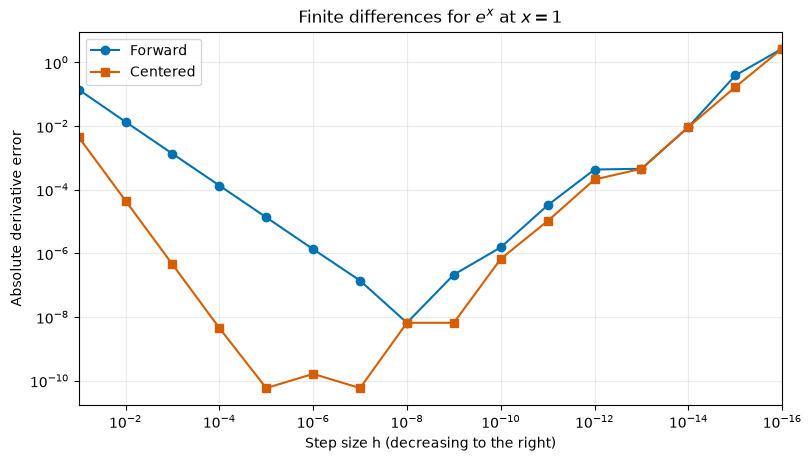

本次前向差分最小误差对应的步长： 1e-08
本次中心差分最小误差对应的步长： 1e-05


In [18]:
# 共用对数坐标比较两种差分；横轴按当前 steps 顺序向右缩小。
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.loglog(
    steps, forward_errors, "o-", color="#0072B2", label="Forward", nonpositive="mask"
)
ax.loglog(
    steps, centered_errors, "s-", color="#D55E00", label="Centered", nonpositive="mask"
)
ax.set(
    xlim=(steps[0], steps[-1]),
    xlabel="Step size h (decreasing to the right)",
    ylabel="Absolute derivative error",
    title=r"Finite differences for $e^x$ at $x=1$",
)
ax.grid(which="both", alpha=0.25)
ax.legend()
# 两条曲线先下降再回升；不能只挑最右侧点作为最佳近似。
plt.show()

# 在本次离散步长集合中找最小误差位置，并非求出普遍最优步长。
forward_best = np.argmin(forward_errors)
centered_best = np.argmin(centered_errors)
print("本次前向差分最小误差对应的步长：", steps[forward_best])  # 本次测试的步长集合中，前向差分在 h=1e-8 处误差最小。
print("本次中心差分最小误差对应的步长：", steps[centered_best])  # 本次测试的步长集合中，中心差分在 h=1e-5 处误差最小。

### 8.4 中心差分可能掩盖不可导点

回到 $f(x)=|x|$ 在 $a=0$ 的情形。对任意 $h>0$，中心差分都是

$$\frac{|h|-|-h|}{2h}=0.$$

这个稳定的数值并不是 $f'(0)$：之前的左右差商分别是 $-1$ 和 $1$。中心相减恰好抵消了两侧变化，不能凭一个对称公式的收敛判定可导。

同样，在 $\ln x$ 的 $a>0$ 处使用中心差分，必须满足 $0<h<a$；靠近定义域边界时应先检查采样位置，再决定公式与步长。

In [19]:
for h in (0.1, 0.01, 0.001):
    left = (abs(0.0) - abs(-h)) / h
    right = (abs(h) - abs(0.0)) / h
    centered = (abs(h) - abs(-h)) / (2 * h)
    print(f"h={h:.3f}，左={left:.1f}，右={right:.1f}，中心={centered:.1f}")  # 三组均为左 -1、右 1、中心 0；中心值不能消除左右不一致。
# 中心结果始终为 0，但左右结果不相等，原点仍不可导。

h=0.100，左=-1.0，右=1.0，中心=0.0
h=0.010，左=-1.0，右=1.0，中心=0.0
h=0.001，左=-1.0，右=1.0，中心=0.0


## 9 综合应用：用局部变化率预测温度

### 9.1 写清模型、单位和导数

下面是人工设定的教学模型，不是实测数据：$T(t)=T_{\mathrm{amb}}+A e^{-t/\tau}$，其中 $t\geq0$ 为经过时间，单位为分钟；$T$ 为温度，单位为摄氏度。取环境温度 $T_{\mathrm{amb}}=20$、初始温差 $A=60$、时间常数 $\tau=5$ 分钟，因此指数 $t/\tau$ 无量纲。

用链式法则求导，常数项为 0，指数外层导数保留指数函数，内层 $-t/\tau$ 的导数为 $-1/\tau$：

$$T'(t)=-\frac{A}{\tau}e^{-t/\tau}=-12e^{-t/5}.$$

其单位为摄氏度每分钟。在 $t_0=5$ 分钟，$T(t_0)=20+60/e$，$T'(t_0)=-12/e$。负号表示温度此时下降；局部预测为 $T(t_0+\Delta t)\approx T(t_0)+T'(t_0)\Delta t$。

In [20]:
ambient = 20.0
amplitude = 60.0
time_constant = 5.0


def temperature(time):
    return ambient + amplitude * np.exp(-time / time_constant)


t0 = 5.0
temperature_at_t0 = temperature(t0)
rate = -amplitude / time_constant * np.exp(-t0 / time_constant)
print(f"5 min 时温度：{temperature_at_t0:.6f} °C")  # 预期约为 42.0728 °C。
print(f"局部变化率：{rate:.6f} °C/min")  # 预期约为 -4.41455 °C/min。

h = 0.01
centered_rate = (temperature(t0 + h) - temperature(t0 - h)) / (2 * h)
print(f"中心差分的变化率：{centered_rate:.6f} °C/min")  # 预期约为 -4.41456 °C/min。
print(f"与解析导数的绝对差：{abs(centered_rate - rate):.3e} °C/min")  # 预期约为 2.943e-06 °C/min。
# 约 42.073 °C、-4.415 °C/min；差分与解析式接近只是数值核对。

5 min 时温度：42.072766 °C
局部变化率：-4.414553 °C/min
中心差分的变化率：-4.414556 °C/min
与解析导数的绝对差：2.943e-06 °C/min


### 9.2 改变预测距离，再检查误差

保持同一切点 $t_0$，分别预测 0.1、0.5、1、3 分钟后的温度。这里只改变预测跨度，不重新拟合切线。

图中蓝线表示设定模型，橙色虚线表示局部线性近似；右图的有符号误差定义为“模型值减预测值”。横纵轴单位不同，温度图不强求一比一比例。误差图用于判断这个预测在所画时间范围内偏高还是偏低。

跨度 0.1 min，预测 41.6313 °C，模型值 41.6357 °C，误差 +0.0044 °C
跨度 0.5 min，预测 39.8655 °C，模型值 39.9723 °C，误差 +0.1068 °C
跨度 1.0 min，预测 37.6582 °C，模型值 38.0717 °C，误差 +0.4134 °C
跨度 3.0 min，预测 28.8291 °C，模型值 32.1138 °C，误差 +3.2847 °C


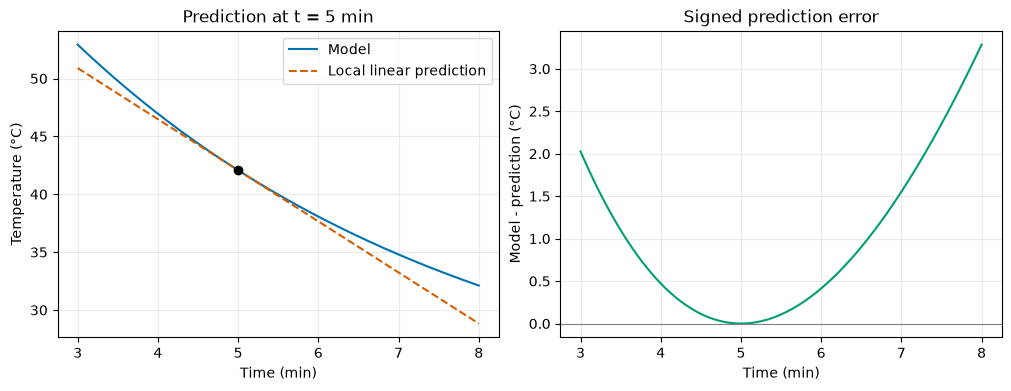

In [21]:
# 固定切点与导数，只改变预测跨度，逐个比较线性预测和原模型。
for duration in (0.1, 0.5, 1.0, 3.0):
    prediction = temperature_at_t0 + rate * duration
    actual = temperature(t0 + duration)
    # 跨度从 0.1 增至 3 min，预测误差从约 +0.0044 增至 +3.2847 °C。
    print(
        f"跨度 {duration:.1f} min，预测 {prediction:.4f} °C，"
        f"模型值 {actual:.4f} °C，误差 {actual - prediction:+.4f} °C"
    )

# 再用连续网格画出两条曲线；右图单独显示模型值减预测值。
times = np.linspace(3, 8, 251)
actual_values = temperature(times)
linear_values = temperature_at_t0 + rate * (times - t0)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), layout="constrained")
axes[0].plot(times, actual_values, color="#0072B2", label="Model")
axes[0].plot(
    times, linear_values, "--", color="#D55E00", label="Local linear prediction"
)
axes[0].scatter([t0], [temperature_at_t0], color="black", zorder=3)
axes[0].set(
    xlabel="Time (min)", ylabel="Temperature (°C)", title="Prediction at t = 5 min"
)
axes[0].legend()
axes[1].plot(times, actual_values - linear_values, color="#009E73")
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].set(
    xlabel="Time (min)",
    ylabel="Model - prediction (°C)",
    title="Signed prediction error",
)
for ax in axes:
    ax.grid(alpha=0.25)
# 两条温度曲线在切点相接；本区间中线性预测偏低，离切点较远时误差更明显。
plt.show()

## 本章小结

（1）极限描述邻近输入的行为；连续还要求该点的函数值与极限相同。左右极限不一致时，修改一个点的取值不能修复跳跃。

（2）导数是差商的有限极限，同时表示切线斜率与局部变化率。可导必连续，但尖角和无界差商说明连续未必可导；端点要说明单侧含义。

（3）求导先确认定义域，再识别和、积、商及复合结构。链式法则要在内层函数值处计算外层导数，并乘以内层导数。

（4）线性近似用于局部预测；有限差分用于数值近似。两者都需要检查尺度，差分还要检查两侧行为与浮点误差。

自查：为什么极限存在仍可能不连续？为什么中心差分给出稳定的 0，仍不能认定某点导数为 0？

## 练习

（1）补上一个点，让函数连续

设 $f(x)=(x^3-8)/(x-2)$（$x\ne2$），$f(2)=k$。先因式分解求 $x\to2$ 的极限，再确定连续所需的 $k$。用两侧输入核对；不要直接计算原分式在 2 处的值。

核对标准：给出约分成立的条件，区分原分式与补值后的函数，并说明有限抽样为什么不能替代极限证明。

In [22]:
offsets = np.array([-0.1, -0.01, 0.01, 0.1])
x = 2 + offsets
# 补充：计算两侧函数值，写出极限以及连续所需的 k。

（2）连续的拼接一定平滑吗

定义 $F(x)=x^2+2x$（$x\leq0$），$F(x)=ax+b$（$x>0$），其中 $a,b$ 为实常数。分别求在 0 处连续、在 0 处可导所需的条件，再给出一组连续但不可导的参数。

核对标准：分别写出左右极限和左右差商。不能只比较函数值，也不能仅由图像看似连接判断可导。

In [23]:
steps = [0.1, 0.01, 0.001]
# 补充：先手算 a、b 的条件，再代入一组参数核对左右差商。

（3）复合求导与局部预测

对 $f(x)=e^{-x^2}$，写出内层、外层及 $f'(x)$。在 $a=1$ 处用线性近似预测 $f(1.05)$，再与直接求值比较。随后把增量改成 0.5，观察误差的变化。

核对标准：导数保留内层的因子；误差明确使用“真实函数值减预测值”，并解释为什么更远处的预测需要重新检查。

In [24]:
def exercise_function(x):
    return np.exp(-(x**2))


a = 1.0
increments = [0.05, 0.5]
# 补充：写出解析导数、两个预测值与对应误差。

（4）靠近定义域边界时选择差分步长

对 $f(x)=\ln x$，在 $a=0.01$ 处比较候选步长 0.02、0.005、0.001、0.0001。先判断哪些允许中心差分，再对合法步长比较中心差分、前向差分及解析导数。

核对标准：不把非正输入传给实数对数；指出“合法采样”和“近似准确”是两个不同要求。额外缩小步长时，应观察一组结果，不默认最小步长最好。

In [25]:
a = 0.01
steps = [0.02, 0.005, 0.001, 0.0001]
# 补充：先判断 a-h 是否大于 0，再计算合法差分和绝对误差。

## 练习提示与解析

以下对应练习（2）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：先让两段在连接点连续，再比较左右差商。

提示 2：右侧差商含有 b/h；连续条件成立后才可把它化为有限的斜率。

### 练习（2）参考解析

$F(0)=0$，左极限为 0，右极限为 b，因此连续当且仅当 $b=0$。在此前提下，左差商为 $h+2$，随 $h\to0^-$ 趋于 2；右差商为 a，所以可导还要求 $a=2$。

例如 $(a,b)=(1,0)$ 给出连续但不可导的拼接：左右斜率分别为 2、1。图像连接只能帮助观察连续性，不能替代差商极限。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| OpenStax — Calculus Volume 1 | [§2.2 The Limit of a Function](https://openstax.org/books/calculus-volume-1/pages/2-2-the-limit-of-a-function)：极限的直观定义、单侧与双侧极限；[§2.3 The Limit Laws](https://openstax.org/books/calculus-volume-1/pages/2-3-the-limit-laws)：Theorems 2.4–2.5 的运算法则与分母非零条件；[§2.4 Continuity](https://openstax.org/books/calculus-volume-1/pages/2-4-continuity)：点处连续的三个条件、可去与跳跃间断、左右连续；[§2.5 The Precise Definition of a Limit](https://openstax.org/books/calculus-volume-1/pages/2-5-the-precise-definition-of-a-limit)：ε–δ 定义；[§3.1 Defining the Derivative](https://openstax.org/books/calculus-volume-1/pages/3-1-defining-the-derivative)：差商、切线与变化率；[§3.2 The Derivative as a Function](https://openstax.org/books/calculus-volume-1/pages/3-2-the-derivative-as-a-function)：可导推出连续、绝对值反例；[§3.3 Differentiation Rules](https://openstax.org/books/calculus-volume-1/pages/3-3-differentiation-rules)：常数、幂、和、乘积与商法则及乘积法则证明；[§3.5](https://openstax.org/books/calculus-volume-1/pages/3-5-derivatives-of-trigonometric-functions)：正弦与余弦导数；[§3.6 The Chain Rule](https://openstax.org/books/calculus-volume-1/pages/3-6-the-chain-rule)：复合求导的条件与求值位置；[§3.9](https://openstax.org/books/calculus-volume-1/pages/3-9-derivatives-of-exponential-and-logarithmic-functions)：指数、自然对数与实指数幂；[§4.2](https://openstax.org/books/calculus-volume-1/pages/4-2-linear-approximations-and-differentials)：点处线性近似及局部范围。 |
| MIT OpenCourseWare — 18.01SC | [Secants and Tangents](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/resources/mit18_01scf10_ex01sol/)：解答 PDF 第 1–4 页，割线与切线的比较和步长依赖；[Continuous but not Smooth](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/resources/mit18_01scf10_ex04sol/)：解答 PDF 第 1 页，分段函数连续与可导条件；[Do We Need the Quotient Rule?](https://ocw.mit.edu/courses/18-01sc-single-variable-calculus-fall-2010/resources/mit18_01scf10_ex11sol/)：解答 PDF 第 1–2 页，商、积与复合求导结果的代数核对。 |
| Fundamentals of Numerical Computation — 作者教材 | [§5.4 Finite differences](https://fncbook.com/finitediffs/)：§5.4.1 的前向、后向与中心差分，式 5.4.2–5.4.5；[§5.5 Convergence of finite differences](https://fncbook.com/fd-converge/)：截断误差定义，§5.5.2 的相减消减与舍入误差，Example 5.5.4 的步长误差实验。 |
| NumPy 2.5 官方文档 | [numpy.exp](https://numpy.org/doc/stable/reference/generated/numpy.exp.html)、[numpy.log](https://numpy.org/doc/stable/reference/generated/numpy.log.html) 的逐元素自然指数与对数；[numpy.logspace](https://numpy.org/doc/stable/reference/generated/numpy.logspace.html) 的 start、stop、num 与 base 参数。 |
| Matplotlib 3.11 官方文档 | [Axes.loglog](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.loglog.html) 的双对数轴与 nonpositive；[Axes.set_aspect](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_aspect.html) 的 equal 比例；[pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) 和 [pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html) 的图形创建与展示。 |